## Apriori Algorithm - Exercise - Solutions

In this exercise, we will apply the Apriori algorithm to discover interesting association rules in a dataset. Unlike traditional exercises that often utilize retail datasets, we will explore a different domain to uncover patterns and relationships.

### Drug Review Dataset

For this exercise, we will use the [**Drug Review Dataset**](https://archive.ics.uci.edu/dataset/462/drug+review+dataset+drugs+com) available from the UCI Machine Learning Repository. This dataset provides patient reviews on specific drugs along with related conditions and a 10-star patient rating reflecting overall patient satisfaction.

### Dataset Details
-   **Content**: The dataset includes patient reviews describing the effectiveness of the drug, side effects experienced, and overall satisfaction.
-   **Attributes**:
    -   `drugName`: Name of the drug.
    -   `condition`: Name of the condition treated.
    -   `review`: Text of the patient's review.
    -   `rating`: 10-star rating system.
    -   `date`: Date of review.
    -   `usefulCount`: Number of users who found the review useful.

### Tasks

1.  **Preprocessing**: Clean the data by handling missing values, filtering noise, and preparing the data for analysis.
2.  **Apriori Setup**: Define support and confidence levels for the Apriori algorithm. Convert the reviews into an appropriate format (like binary encoding) for association rule mining.
3.  **Rule Generation**: Apply the Apriori algorithm to discover frequent itemsets and generate association rules.
4.  **Analysis**: Analyze the resulting rules to identify the most significant associations between drugs and patient-reported outcomes.

In [1]:
# !pip install mlxtend
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading
Load the dataset into a pandas DataFrame.

In [2]:
# Assuming the dataset is stored in a CSV file named 'drug-review.csv'
df = pd.read_csv('drugs-review.csv', sep=';')
df.head()

,ID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9.0,"May 20, 2012",27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8.0,"April 27, 2010",192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5.0,"December 14, 2009",17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8.0,"November 3, 2015",10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9.0,"November 27, 2016",37


## Exploratory Data Analysis (EDA)

Let's perform some basic exploratory data analysis to understand our dataset.


In [3]:
# Statistical summary of numerical features
df.describe()

,ID,rating,usefulCount
count,161297.000000,161297.000000,161297.000000
mean,115923.585305,6.994377,28.004755
std,67004.445170,3.272329,36.403742
min,2.000000,1.000000,0.000000
25%,58063.000000,5.000000,6.000000
50%,115744.000000,8.000000,16.000000
75%,173776.000000,10.000000,36.000000
max,232291.000000,10.000000,1291.000000


In [4]:
# Checking for missing values
df.isnull().sum()

ID               0
drugName         0
condition      899
review           0
rating           0
date             0
usefulCount      0
dtype: int64

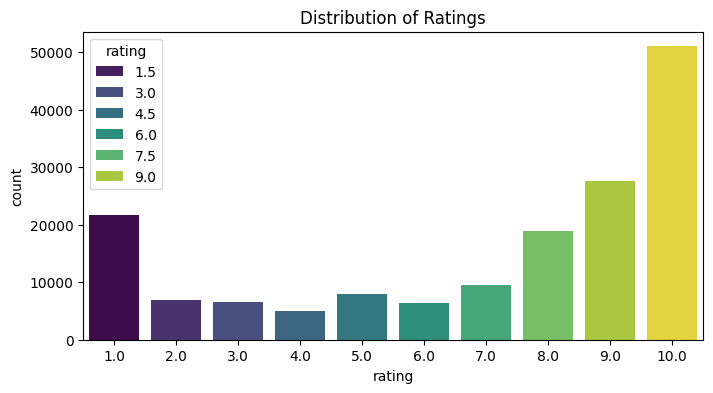

In [5]:
# Distribution of ratings
plt.figure(figsize=(8,4))
sns.countplot(x='rating', data=df, palette='viridis', hue='rating')
plt.title('Distribution of Ratings')
plt.show()

In [6]:
# Number of unique drugs and conditions
print(f"Unique drugs: {df['drugName'].nunique()}")
print(f"Unique conditions: {df['condition'].nunique()}")

Unique drugs: 3436
Unique conditions: 884


## Data Preprocessing

Before applying the Apriori algorithm, we need to preprocess our data.

In [7]:
# Handle missing values by removing or imputing
df.dropna(subset=['condition', 'drugName'], inplace=True)

## Create a new DataFrame for Apriori analysis

In [8]:
# Encode 'drugName' as columns with binary values where 1 indicates the presence of the drug in the review
drug_dummies = pd.get_dummies(df['drugName'])
condition_dummies = pd.get_dummies(df['condition'])

# Combine drug and condition data (optional, depending on whether you want to include conditions)
apriori_df = pd.concat([df['review'], drug_dummies, condition_dummies], axis=1)

# Drop duplicates to ensure that each review's unique combination of drug and condition is only represented once
apriori_df = apriori_df.drop_duplicates().set_index('review')

# Check the resulting DataFrame
apriori_df.head(1)

,A + D Cracked Skin Relief,A / B Otic,Abacavir / dolutegravir / lamivudine,Abacavir / lamivudine / zidovudine,Abatacept,Abilify,Abilify Discmelt,Abilify Maintena,Abiraterone,AbobotulinumtoxinA,...,moterol),mulation) (phenylephrine),t Care,t Pac with Cyclobenzaprine (cyclobenzaprine),tic (mycophenolic acid),unctional Gastric Disorde,ungal Infection Prophylaxis,ungal Pneumonia,von Willebrand's Disease,zen Shoulde
review,,,,,,,,,,,,,,,,,,,,,
"""It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil""",False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Apply the Apriori Algorithm

Next, we apply the Apriori algorithm to discover frequent itemsets in the transformed dataset. We then derive association rules from these itemsets.

In [9]:
from mlxtend.frequent_patterns import apriori, association_rules

# Apply the Apriori algorithm to find frequent itemsets
# Note: Adjust min_support to find meaningful patterns, typically starting with a lower threshold
frequent_itemsets = apriori(apriori_df, min_support=0.01, use_colnames=True)

# Generating the association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.01)  # Threshold for confidence can be adjusted

# Display the top association rules sorted by confidence
print("Number of rules:", len(rules))
rules.sort_values(by='confidence', ascending=False).head()

Number of rules: 8


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
3,(Etonogestrel),(Birth Control),0.020711,0.179491,0.020668,0.997892,5.559571,0.016950,389.272980,0.837475
7,(Nexplanon),(Birth Control),0.013446,0.179491,0.013402,0.996753,5.553226,0.010989,252.716816,0.831099
1,(Ethinyl estradiol / norethindrone),(Birth Control),0.017144,0.179491,0.014568,0.849764,4.734300,0.011491,5.461452,0.802534
5,(Levonorgestrel),(Birth Control),0.022638,0.179491,0.013277,0.586501,3.267584,0.009214,1.984309,0.710037
2,(Birth Control),(Etonogestrel),0.179491,0.020711,0.020668,0.115145,5.559571,0.016950,1.106723,0.999538


### Analysis of the Rules

We will examine the generated rules based on confidence and lift, which are key metrics for evaluating the strength and usefulness of the discovered associations.

In [10]:
# Filter rules with high lift and confidence
high_confidence = 0.5
high_lift = 1

selected_rules = rules[(rules['confidence'] > high_confidence) & (rules['lift'] > high_lift)]
selected_rules.sort_values(by='lift', ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
3,(Etonogestrel),(Birth Control),0.020711,0.179491,0.020668,0.997892,5.559571,0.016950,389.272980,0.837475
7,(Nexplanon),(Birth Control),0.013446,0.179491,0.013402,0.996753,5.553226,0.010989,252.716816,0.831099
1,(Ethinyl estradiol / norethindrone),(Birth Control),0.017144,0.179491,0.014568,0.849764,4.734300,0.011491,5.461452,0.802534
5,(Levonorgestrel),(Birth Control),0.022638,0.179491,0.013277,0.586501,3.267584,0.009214,1.984309,0.710037
